In [1]:
pth = "/home/pos-control/Andrin/LAB-Positioner-Daemon"
import sys
sys.path.append(pth)
from positioner.lab.Thorlabs.CS126MU import CS126MU
cam1 = CS126MU()

In [2]:
import positioner.lab.RND.RND320_KA3005P as RND
powersupply = RND("/dev/ttyACM3", log=None)

SerialException: [Errno 2] could not open port /dev/ttyACM3: [Errno 2] No such file or directory: '/dev/ttyACM3'

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
from PIL import Image
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cv2
import time


def enhance_contrast(image_path,threshold_value = 5, save = False):
    
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

    print("Original dtype: ", img.dtype)
    print("Min/Max before: ", img.min(), img.max())

    img = img.astype(np.float32) #Covert to float for scaling$
    #img = cv2.blur(img, (3,3))
    _, img = cv2.threshold(img, threshold_value, img.max(), cv2.THRESH_TOZERO)

    print("Min/Max after blurring: ", img.min(), img.max())

    #stretched = (img - img.min())*(4095/(img.max()-img.min()))
    #stretched = np.clip(stretched, 0, 4095)
    plt.imshow(img, cmap='inferno', origin='upper', norm=mpl.colors.LogNorm()) #1,100))
    plt.colorbar(label='Intensity')
    plt.title("Logarithmic Intensity Plot with threshold @" +str(threshold_value))
    plt.axis()
    plt.grid(True)
    if(save):
        plt.savefig("tilt-test/plots/" +str(time.time())+".png", dpi=300, bbox_inches='tight')
    plt.show()
    #cv2.imwrite("streched/1.tif", stretched.astype(np.uint16))
    #print("Min/Max after: ", stretched.min(), stretched.max())

def plot_tiff_logscale(image_path, save = False):
    # Load 16-bit grayscale image
    img = Image.open(image_path)
    
    if img.mode != 'I;16':
        img = img.convert('I;16')

    img_array = np.array(img, dtype=np.uint16)


    # Plot with a colormap (e.g. 'viridis', 'inferno', 'plasma')
    plt.imshow(img_array, cmap='inferno', origin='upper', norm=mpl.colors.LogNorm())
    plt.colorbar(label='Intensity')
    plt.title("Logarithmic Intensity Plot")
    plt.axis('off')
    plt.grid(True)
    if(save):
        plt.savefig(os.path.join(os.path.dirname(fullPath),str(time.time())+".png"), dpi=300, bbox_inches='tight')
    plt.show()

In [5]:
import os

In [6]:
! hostname

pos-control


First Image: Bit Depth = 12 bpp, Exposure Time = 9.996 ms
First Image: Bit Depth = 12 bpp, Exposure Time = 9.996 ms
First Image: Bit Depth = 12 bpp, Exposure Time = 9.996 ms
First Image: Bit Depth = 12 bpp, Exposure Time = 9.996 ms
First Image: Bit Depth = 12 bpp, Exposure Time = 9.996 ms


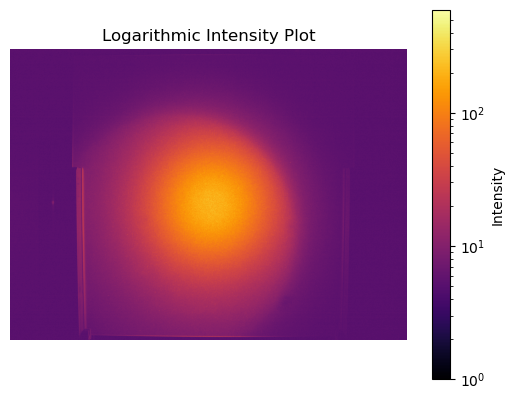

In [18]:
stagePos = 20
writeDir = "./imgs/metrologyScan2/yScan"
outDir = os.path.join(writeDir,str(stagePos))
os.makedirs(outDir,exist_ok=True)

for k in range(5):
    cam1.setExposure(10000)
    cam1.poll_Timeout_ms = 15000
    path = cam1.saveImage(outDir)

fullPath = os.path.join(outDir,path)

plot_tiff_logscale(fullPath,False)

In [ ]:
img = cv2.imread(fullPath, cv2.IMREAD_UNCHANGED)

In [ ]:
np.nanpercentile(img.flatten(),(1,50,95,99)),np.std(img.flatten())

In [ ]:
plt.imshow(np.array(img)-5,origin='lower',vmin=-0.5,vmax=0.5)
plt.colorbar()

In [ ]:
# np.array(img)

(array([0.000000e+00, 3.516000e+03, 9.140000e+03, 2.055550e+05,
        1.801365e+06, 5.221071e+06, 3.998598e+06, 9.643250e+05,
        7.929100e+04]),
 array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.]),
 <BarContainer object of 9 artists>)

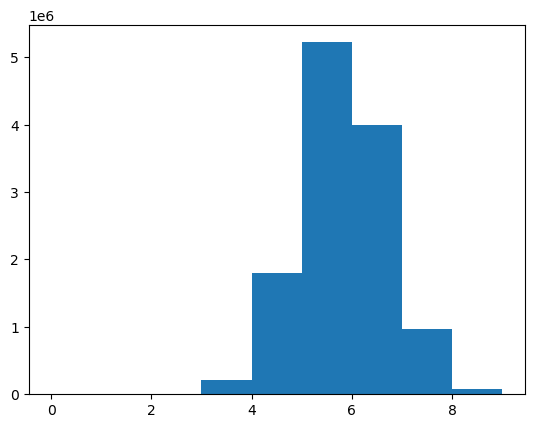

In [16]:
plt.hist(img.flatten(),bins=np.arange(0,10,step=1))

In [ ]:
for k in  range(10):
    for i in range(10):
        cam1.setExposure(int(100000/(k+1)))
        path = cam1.takeImage()
        
        
        """img = Image.open("Images/"+path)
        
        if img.mode != 'I;16':
            img = img.convert('I;16')
        
        img_array = np.array(img, dtype=np.uint16)
        print(img_array.max())
        
        
        
        plt.imshow(img_array, cmap='inferno', origin='upper', norm=mpl.colors.LogNorm(1,4095))
        plt.colorbar(label='log10(Intensity + 1)')
        plt.title("Logarithmic Intensity Plot")
        plt.axis('off')
        plt.savefig("/home/pos-control/Andrin/Tholabs_Cam/log_plots/log_intensity_plot_" +path[:-4]+".png", dpi=300, bbox_inches='tight')
"""

In [7]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def analyze_max_intensity(image_path, show_plot=True):
    # Load 16-bit grayscale image
    img = Image.open(image_path)
    if img.mode != 'I;16':
        img = img.convert('I;16')
    img_array = np.array(img, dtype=np.uint16)

    # Find the maximum intensity value
    max_val = img_array.max()

    # Find all (row, col) positions of the max value
    max_positions = np.argwhere(img_array == max_val)
    max_count = max_positions.shape[0]

    # Print results
    print(f"Maximum intensity value: {max_val}")
    print(f"Number of pixels with that value: {max_count}")duty_cycle
    print(f"Pixel positions (row, col):")
    for pos in max_positions:
        print(tuple(pos))
        
    return max_positions
    
    # Optional: Show plot with highlighted max pixels
    if show_plot:
        plt.figure(figsize=(8, 6))
        plt.imshow(np.log10(img_array + 1), cmap='gray')
        plt.scatter(max_positions[:,1], max_positions[:,0], color='red', s=10, label='Max Intensity Pixels')
        plt.title("Max Intensity Pixel Locations")
        plt.legend()
        plt.axis('off')
        plt.tight_layout()
        plt.show()

   




4090


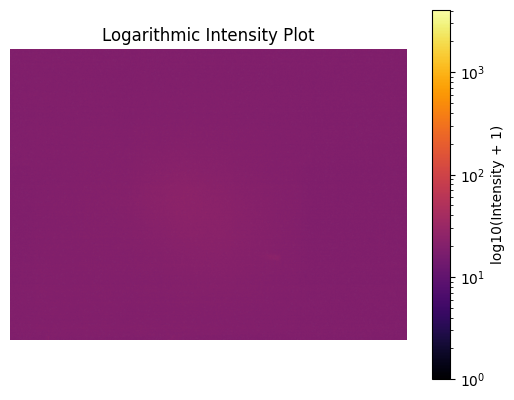

In [30]:
 
img = Image.open("streched/1.tif")

if img.mode != 'I;16':
    img = img.convert('I;16')

img_array = np.array(img, dtype=np.uint16)
print(img_array.max())

plt.imshow(img_array, cmap='inferno', origin='upper', norm=mpl.colors.LogNorm(1,4095))
plt.colorbar(label='log10(Intensity + 1)')
plt.title("Logarithmic Intensity Plot")
plt.axis('off')
plt.savefig("/home/pos-control/Andrin/Tholabs_Cam/log_plots/log_intensity_plot_1.png", dpi=300, bbox_inches='tight')
